<a href="https://colab.research.google.com/github/sugamthapa47/SugamThapa_INFO4670_Spring2026/blob/main/Logistic_Regression_Car_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 11: Assignment 4 - Logistic Regression Assignment (Age & Salary → Purchased)
**Coures:** INFO 4670 Fengjiao Tu  
**Goal:** Train and evaluate a Logistic Regression model to predict whether a customer purchases a car using `Age` and `Salary`.

---

## I. Assignment Objective
By completing this assignment, you will:
- Understand the concept and intuition of logistic regression.
- Load and preprocess data using `pandas`.
- Train and evaluate a logistic regression model with `scikit-learn`.
- Visualize classification results.
- Analyze model performance and reflect on possible improvements.


## II. Dataset Description
Expected CSV file name: **`car_purchase_data.csv`**

| Column | Description | Example |
|--------|-------------|---------|
| `Age` | Age of the customer | 35 |
| `Salary` | Annual or monthly income | 60000 |
| `Purchased` | Whether the customer purchased a car (1 = Yes, 0 = No) | 1 |


---
# Grading Rubric (Total = 100 points)

| Section | Description | Points | Details |
|--------|-------------|--------|---------|
| **Objective Understanding** | Explain purpose and logic of logistic regression | 10 | Goal & rationale (5); why LR for this task (5) |
| **Data Preparation** | Data loading, splitting, scaling | 20 | Import & preview (5); X/y split (5); train/test (5); scaling (5) |
| ** Model Training & Evaluation** | Fit, predict, metrics, visualization | 40 | Trained correctly (10); metrics shown (10); **accuracy ≥ 87.5% (10)**; visualization (10) |
| ** Analysis & Reflection** | Interpretation and critical thinking | 30 | Probability→class explanation (10); result discussion (10); improvements (10) |


**Accuracy Requirement:**
- Full credit (10 pts) if **accuracy ≥ 87.5%**
- Partial (7–9 pts) if **80% ≤ accuracy < 87.5%**
- Minimal (≤5 pts) if **accuracy < 80%**
- 0 pts if the model fails to run


## III. Steps to Complete
Follow the cells below in order. According to the hands-on task, please complete the code.

### Step 1: Import libraries and load data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('car_purchase_data.csv')
df.head()

,User ID,Gender,Age,Salary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


### Step 2: Split features and target

In [4]:
X = df[['Age', 'Salary']]
y = df['Purchased']

### Step 3: Train/Test Split

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0
)

### Step 4: Feature Scaling

In [6]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

### Step 5: Train Logistic Regression Model

In [7]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(random_state=0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

### Step 6: Predict and Evaluate

In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = classifier.predict(X_test)

print("Predictions:")
print(y_pred)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nAccuracy:", accuracy_score(y_test, y_pred))

Predictions:
[0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0
 0 0 1 0 1 1 1 1 0 0 1 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1]

Confusion Matrix:
[[65  3]
 [ 8 24]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.96      0.92        68
           1       0.89      0.75      0.81        32

    accuracy                           0.89       100
   macro avg       0.89      0.85      0.87       100
weighted avg       0.89      0.89      0.89       100


Accuracy: 0.89


### Step 7: Visualization of Decision Regions

/tmp/ipykernel_254/1795630800.py:22: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


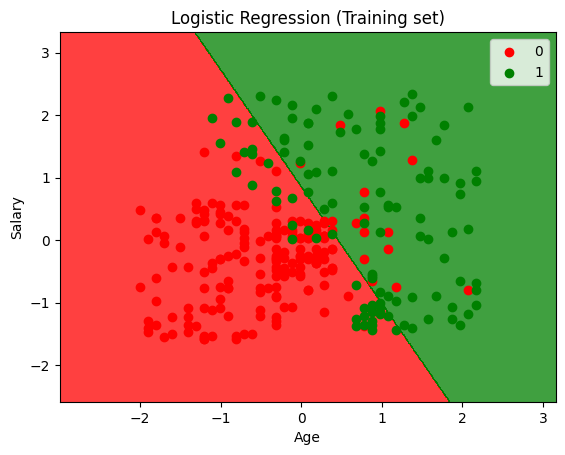

In [9]:
from matplotlib.colors import ListedColormap
import numpy as np
import matplotlib.pyplot as plt

X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
    np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01)
)

plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('red', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0], X_set[y_set == j, 1],
        c=ListedColormap(('red', 'green'))(i),
        label=j
    )

plt.title('Logistic Regression (Training set)')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.legend()
plt.show()

## IV. Reflection Questions
1. Logistic regression outputs probabilities — why can it still be used for classification?
2. Based on your model, which customers are more likely to purchase a car?
3. What factors might cause low accuracy in this task?
4. Propose additional features or preprocessing steps that could improve accuracy.


1. How does logistic regression return probable values? How is this
supposed to help in classification?

Logistic regression approximates a probability that can be treated as a clear yes/no output. Using a cutoff value, most often set by default at 0.5, if the probability calculated is higher than this cutoff, it gets classified as 1 (purchase); otherwise, it's classified as 0 (not purchase). So, even though it gives probabilities, it becomes very handy for classification.




2. Who are those customers according to your model that are more likely to buy a car?
According to the model and the graph, the people who are slightly older in age and earning more wages would be the potential car buyers. People with lesser salaries and those on the younger side mostly fall in the ‘not purchasing’ category.

3. What factors might lead to low accuracy in this task?
In this case, since we are working only on age and salary, it may render limited work. Other more important factors could be considered, like gender, lifestyle, and location. Moreover, there could be point overlaps: some customers with almost the same age and salary may behave differently, making it very hard for the model to separate them perfectly.

4. Suggest more features or preprocessing that can be done to further improve accuracy.
It may increase accuracy to include more features, like data related to gender, job type, or spending habits. Another possible way for improving accuracy is to perform data cleaning with the help of techniques like outlier removal. Other models include Random Forest, or further tuning the same model.